# Lab 1 Submission by Ghulam Mujtaba Sahto (507985)

### Import the necessary libraries

In [407]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

### Load the Stanford manipulator model from Robotics Toolbox.
### This robot is selected as an alternative to Puma560.
### The model includes kinematic and dynamic parameters based on the DH convention.

In [408]:
robot = rtb.models.DH.Stanford()
#print robot structure
print(robot) 

DHRobot: Stanford arm (by Victor Scheinman), 6 joints (RRPRRR), dynamics, standard DH parameters
┌────────┬───────┬────────┬────────┬─────────────────────┬────────┐
│   θⱼ   │  dⱼ   │   aⱼ   │   ⍺ⱼ   │         q⁻          │   q⁺   │
├────────┼───────┼────────┼────────┼─────────────────────┼────────┤
│  q1    │ 0.412 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q2    │ 0.154 │      0 │  90.0° │             -170.0° │ 170.0° │
│ -90.0° │    q3 │ 0.0203 │   0.0° │ 0.30479999999999996 │   1.27 │
│  q4    │     0 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q5    │     0 │      0 │  90.0° │              -90.0° │  90.0° │
│  q6    │     0 │      0 │   0.0° │             -170.0° │ 170.0° │
└────────┴───────┴────────┴────────┴─────────────────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬─────┬────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2 │ q3  │ q4  │ q5  │
├──────┼─────┼─────┼────┼─────┼─────┼─────┤
│   qr │  0° │  0° │  0 │  0° │  0° │  0° │
│   qz │  0° │  0° │  0 │  0°

### Initial Configuration of robot according to datasheet of the manipulator
#### Fill in the parameters of the robot model stanford

Using dyn() print the dynamic parameters of each link

In [409]:

print(robot.links[0].dyn())

m     =       9.3 
r     =         0    0.018    -0.11 
        |     0.28        0        0 | 
I     = |        0     0.26        0 | 
        |        0        0    0.071 | 
Jm    =      0.95 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =        -3 to        3


print each quantity to verify the values

In [410]:
print(robot.links[0].I)

[[0.276 0.    0.   ]
 [0.    0.255 0.   ]
 [0.    0.    0.071]]


1. Specify the mass of the links

In [411]:
robot.links[0].m = 9.3
robot.links[1].m = 5.01
robot.links[2].m = 4.25
robot.links[3].m = 1.08
robot.links[4].m = 0.63
robot.links[5].m = 0.51

2. Specify the center of the mass of each link

In [412]:
robot.links[0].r = [0, 0.0175, -0.1105]
robot.links[1].r = [0.0, -1.054, 0.0]
robot.links[2].r = [0.0, 0, -6.447]
robot.links[3].r = [0, 0.092, -0.054]
robot.links[4].r = [0, 0.566, 0.003]
robot.links[5].r = [0, 0, 1.554]

3. Specify the Inertia of each link

In [413]:
robot.links[0].I = [0.276, 0.255, 0.071, 0, 0, 0]
robot.links[1].I = [0.108, 0.018, 0.1, 0, 0, 0]
robot.links[2].I = [2.51, 2.51, 0.006, 0, 0, 0]
robot.links[3].I = [0.002, 0.001, 0.001, 0, 0, 0]
robot.links[4].I = [0.003, 0.0004, 0, 0, 0, 0]
robot.links[5].I = [0.013, 0.013, 0.0003, 0, 0, 0]

4. Specify the moment of Inertia of the drive

In [414]:
robot.links[0].Jm = 0.953
robot.links[1].Jm = 2.193
robot.links[2].Jm = 0.782
robot.links[3].Jm = 0.106
robot.links[4].Jm = 0.097
robot.links[5].Jm = 0.02

5. Specify the coefficient of viscous friction of the drive

In [415]:
robot.links[0].B = 0.0
robot.links[1].B = 0.0
robot.links[2].B = 0.0
robot.links[3].B = 0.0
robot.links[4].B = 0.0
robot.links[5].B = 0.0

6. Specify the coefficient of Coulomb friction of the drive

In [416]:
robot.links[0].Tc = [0, 0]
robot.links[1].Tc = [0, 0]
robot.links[2].Tc = [0, 0]
robot.links[3].Tc = [0, 0]
robot.links[4].Tc = [0, 0]
robot.links[5].Tc = [0, 0]

7. Setting up the gear ratio for each link

In [417]:
robot.links[0].G = 1
robot.links[1].G = 1
robot.links[2].G = 1
robot.links[3].G = 1
robot.links[4].G = 1
robot.links[5].G = 1

8. Restrict the generalized coordinates for each link

In [418]:
robot.links[0].qlim = [-2.96705973,  2.96705973]
robot.links[1].qlim = [-2.96705973,  2.96705973]
robot.links[2].qlim = [0.3048, 1.27]
robot.links[3].qlim = [-2.96705973,  2.96705973]
robot.links[4].qlim = [-1.57079633,  1.57079633]
robot.links[5].qlim = [-2.96705973,  2.96705973]

### Set the initial and final positions of the robot and plot them

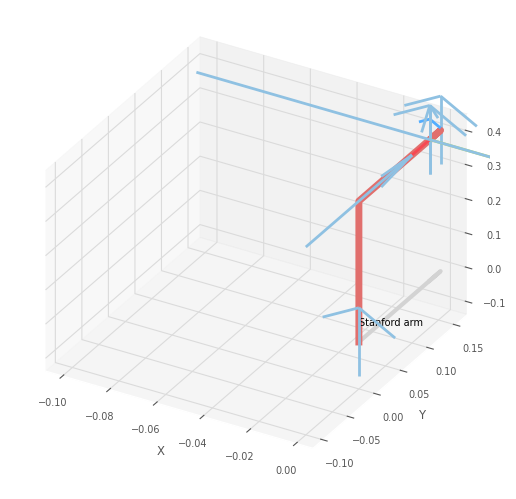

<Figure size 640x480 with 0 Axes>

In [419]:
#Initial position of manipulator
q_start = [0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

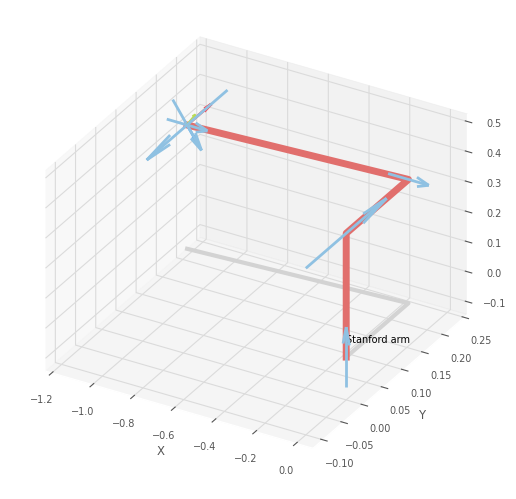

<Figure size 640x480 with 0 Axes>

In [ ]:
#Final position of manipulator
q_end = [0, pi/2, -pi/3, -pi/2, -pi/4, -pi/2]
robot.plot(q_end)
plt.show()

### Time Discretization

In [420]:
# Define the number of trajectory points.
N = 100

# Define start and stop time of motion.
t_start = 0
t_stop = 5

# Compute time step.
t_shag = t_stop / N

### Trajectory Planning

#### Generate a smooth joint-space trajectory using cubic polynomial interpolation.
#### The function jtraj returns position, velocity, and acceleration profiles.

In [421]:
# Generate time vector for trajectory planning.
time = np.arange(t_start, t_stop, t_shag)
tr = rtb.jtraj(q_start, q_end, time)

Extract joint positions, velocities, and accelerations.

In [422]:
q   = tr.q
qd  = tr.qd
qdd = tr.qdd

### Inverse Dynamics (Newton–Euler Method)

#### Case 1: Full dynamics (non-zero velocities and accelerations)

In [423]:
tau_dyn = robot.rne(q, qd, qdd)

#### Case 2: Quasi (velocities present, accelerations negligible) qdd = 0.

In [424]:
tau_quasi = robot.rne(q, qd, np.zeros_like(qdd))

#### Case 3: Static (robot holds position, but no motion) qd = 0, qdd = 0.

In [425]:
tau_static = robot.rne(q, np.zeros_like(qd), np.zeros_like(qdd))

### Computation of M(q), C(q,  qdot), G(q)

In [426]:

# M_dyn = robot.inertia(q)
# C_dyn = robot.coriolis(q, qd)
# G_dyn = robot.gravload(q)

# M_quasi = robot.inertia(q)
# C_quasi = robot.coriolis(q, qd)
# G_quasi = robot.gravload(q)

# M_static = robot.inertia(q)
# C_static = robot.coriolis(q, np.zeros([N,6]))
# G_static = robot.gravload(q)

#Initialize lists to store matrices at each time step.
M_list = []
C_list = []
G_list = []

# Compute dynamic matrices at each point along the trajectory.
for i in range(len(time)):

    #inertia matrix M(q)
    M_list.append(robot.inertia(q[i]))

    #coriolis matrix C(q, qdot)
    C_list.append(robot.coriolis(q[i], qd[i]))

    #gravity vector G(q)
    G_list.append(robot.gravload(q[i]))

#convert lists into arrays.
M_list = np.array(M_list)
C_list = np.array(C_list)
G_list = np.array(G_list)

### Plotting the Joint Torques for all 3 cases

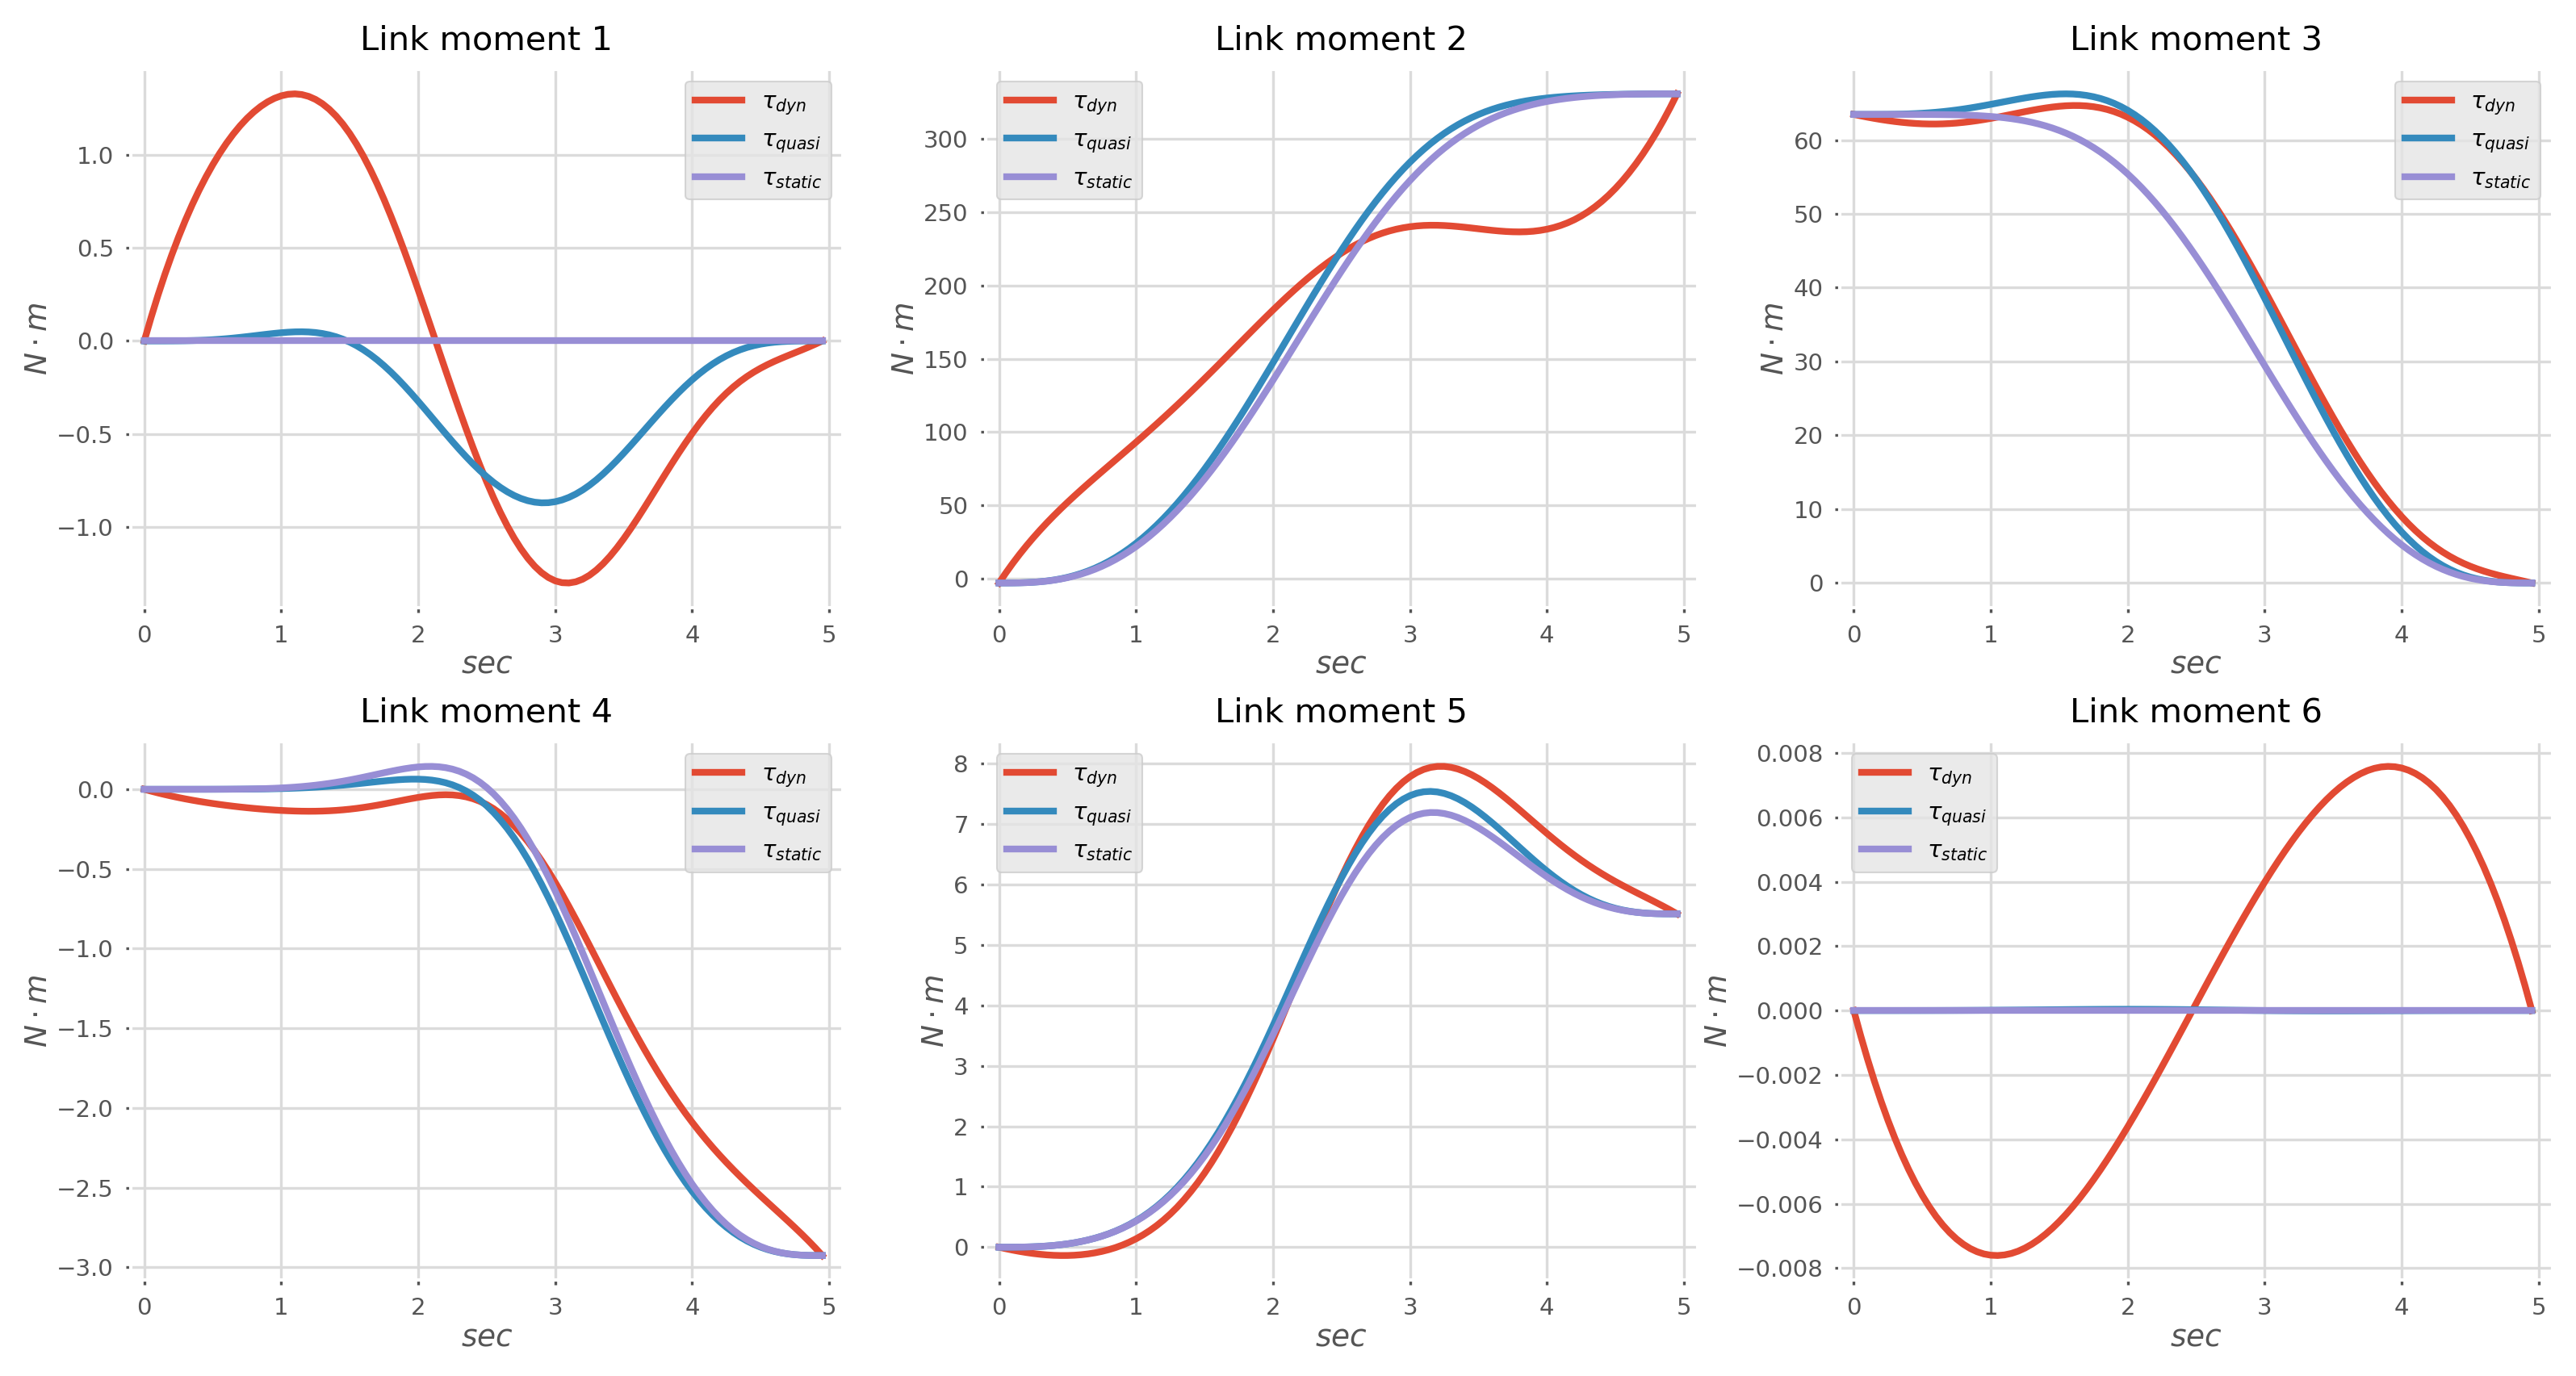

In [427]:
plt.figure(figsize=(10,5), dpi=300)

for g in range(6):
    plt.subplot(2,3,g+1)

    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)

    # Plot torque for dynamic case
    plt.plot(time, tau_dyn[:, g], linewidth=2, label=r"$\tau_{dyn}$") 
    # Plot torque for quasi-static case
    plt.plot(time, tau_quasi[:, g], linewidth=2, label=r"$\tau_{quasi}$")
    # Plot torque for static case
    plt.plot(time, tau_static[:, g], linewidth=2, label=r"$\tau_{static}$")

    plt.title(r"Link moment {}".format(g+1), fontsize=10)
    plt.ylabel(r"$N \cdot m$", fontsize=9)
    plt.xlabel(r"$sec$", fontsize=9)

    plt.grid(True)
    plt.legend()

    ax = plt.gca()
    ax.set_facecolor((1,1,1))
    ax.set_xlim([t_start-0.1, t_stop+0.1])

plt.show()